<a href="https://colab.research.google.com/github/singhal-yash/Student_Performance/blob/main/Student_Perform_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [211]:
# import required modules and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [212]:
# Load the Dataset
data = pd.read_csv('/content/Student_Performance.csv')
data.sample(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
7683,5,96,No,8,5,81.0
981,3,75,No,8,5,57.0
5793,5,86,Yes,5,1,71.0


In [213]:
#Getting information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [214]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


<Axes: ylabel='count'>

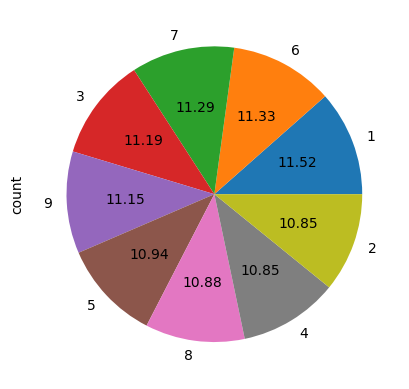

In [215]:
data['Hours Studied'].value_counts().plot(kind='pie', autopct='%0.2f')

<Axes: ylabel='count'>

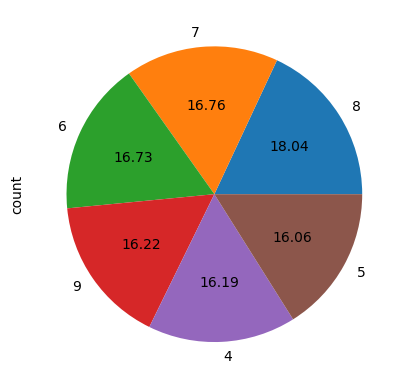

In [216]:
data['Sleep Hours'].value_counts().plot(kind ='pie',autopct= '%0.2f')

<Axes: xlabel='Performance Index', ylabel='Sleep Hours'>

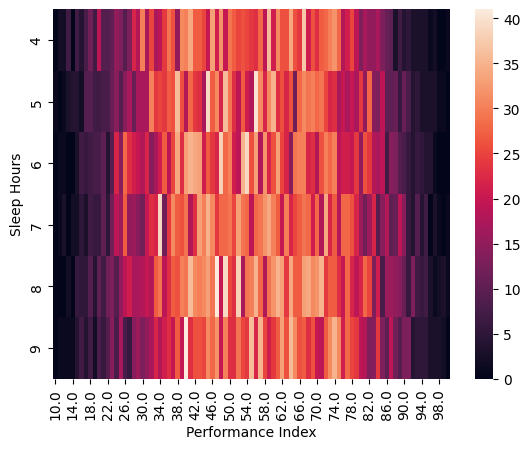

In [217]:
sns.heatmap(pd.crosstab(data['Sleep Hours'],data['Performance Index']))

In [218]:
#Encoding Categorical Data
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['No','Yes']])

oe.fit(data['Extracurricular Activities'].values.reshape(-1,1))

data['Extracurricular Activities'] = oe.transform(data['Extracurricular Activities'].values.reshape(-1,1))


In [219]:
#Correlation Coefficient
data.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

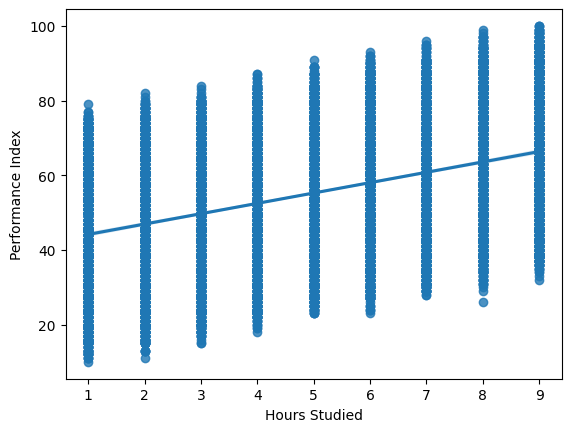

In [220]:

sns.regplot(x ="Hours Studied",y="Performance Index",data = data)

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

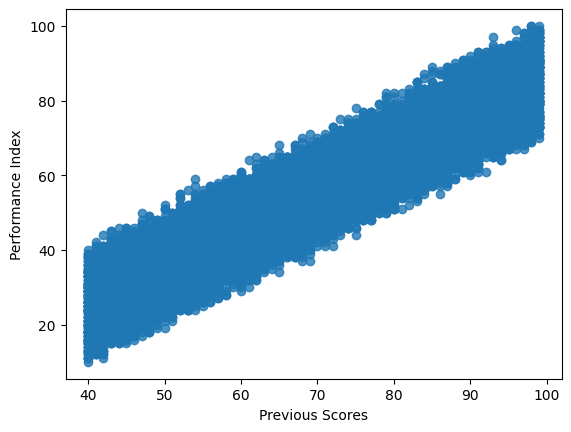

In [221]:
sns.regplot(x ="Previous Scores",y="Performance Index",data = data)

<Axes: xlabel='Sleep Hours', ylabel='Performance Index'>

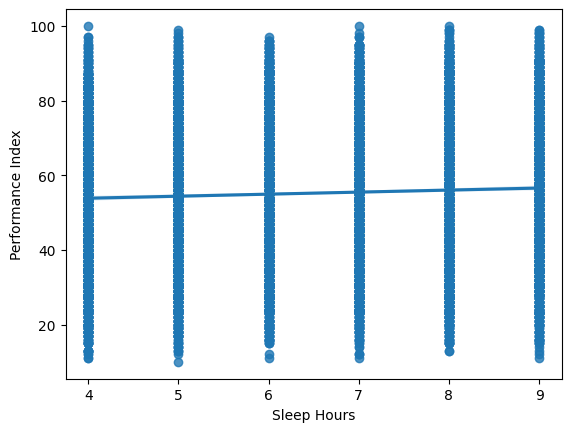

In [222]:
sns.regplot(x ="Sleep Hours",y="Performance Index",data = data)

<Axes: xlabel='Sample Question Papers Practiced', ylabel='Performance Index'>

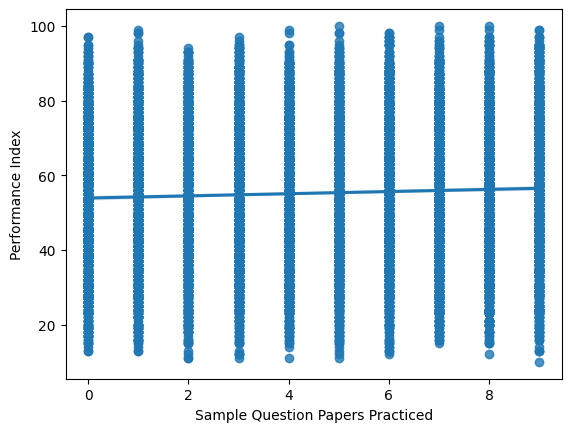

In [223]:
sns.regplot(x ="Sample Question Papers Practiced",y="Performance Index",data = data)

In [224]:
#Divide data into Input features and Output result
X = data.iloc[:,0:-1]
y = data.iloc[:,-1]
X.shape, y.shape

((10000, 5), (10000,))

In [225]:
# Split dataset for Training and Tetsing purpose
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [226]:
#standardize the dataset
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [227]:
x_test

array([[ 0.00594246, -0.03475203, -0.98075655,  0.85931267, -0.91354233],
       [-1.1495368 , -1.36122824,  1.01962103, -1.49819809,  1.17876751],
       [ 0.77626198, -0.78449945,  1.01962103,  0.26993498,  0.13261259],
       ...,
       [ 0.00594246, -1.24588248,  1.01962103, -0.31944271, -0.21610572],
       [-0.76437705,  0.94568691,  1.01962103,  1.44869036,  0.13261259],
       [ 0.39110222, -1.53424687,  1.01962103, -0.31944271, -0.21610572]])

In [228]:
#Train model by Linear Regression
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(x_train, y_train)

LinearRegression()

In [229]:
reg.coef_

array([ 7.42276987, 17.60827303,  0.29080153,  0.8138699 ,  0.54598268])

In [230]:
reg.intercept_

np.float64(55.39971428571428)

In [231]:
#Prediction on test data
y_pred = reg.predict(x_test)
y_pred, y_test.values

(array([54.74728554, 22.61884434, 47.93665124, ..., 33.42451751,
        67.92578967, 31.20587077]),
 array([51., 20., 46., ..., 33., 69., 29.]))

/tmp/ipykernel_2409/3180880144.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, hist = False)


<Axes: ylabel='Density'>

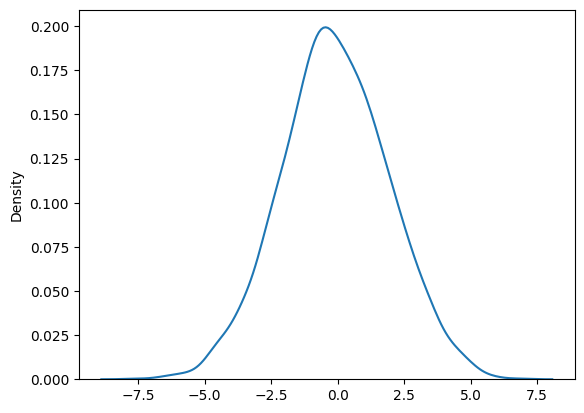

In [232]:
residual = y_test.values - y_pred
sns.distplot(residual, hist = False)

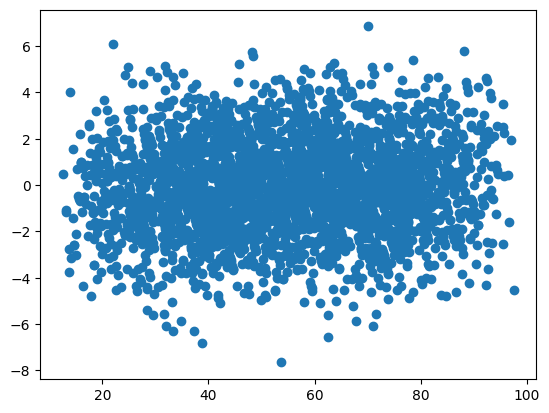

In [233]:
plt.scatter(y_pred, residual)

In [234]:
# MAE, MSE, SMSE, r2 score calculate
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print('MAE', mean_absolute_error(y_test, y_pred) )
print('MSE', mean_squared_error(y_test, y_pred) )
print('SMSE', sqrt(mean_squared_error(y_test, y_pred)))
print('r2 score', r2_score(y_test, y_pred))
r2 =  r2_score(y_test, y_pred)

MAE 1.6090437564045224
MSE 4.066563824092684
SMSE 2.0165722957763466
r2 score 0.9890110607021136


In [235]:
Adjusted_r2_score = 1- (((1-r2)*(len(y_train) + len(y_test)-1))/(len(y_train) + len(y_test)-x_train.shape[1]-1))
print('Adjusted r2 score', Adjusted_r2_score)

Adjusted r2 score 0.9890055629338037
